<h1>Импорт библиотек

In [18]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [49]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    if len(X) != len(V):
        raise ValueError("Количество матриц и векторов должно совпадать.")

    result = np.zeros_like(V[0], dtype=float)

    for matrix, vector in zip(X, V):
        result += matrix @ vector

    return result


A1 = np.array([[1, 0], [0, 1]])
v1 = np.array([[1], [2]])
A2 = np.array([[2, 1], [1, 2]])
v2 = np.array([[1], [1]])

assert np.allclose(sum_prod([A1, A2], [v1, v2]), A1@v1 + A2@v2)
A3 = np.array([[0, 1], [1, 0]])
v3 = np.array([[3], [4]])

assert np.allclose(sum_prod([A1, A2, A3], [v1, v2, v3]),
                   A1@v1 + A2@v2 + A3@v3)

try:
    sum_prod([A1], [v1, v2])
    raise AssertionError("Должен быть ValueError")
except ValueError:
    pass

<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [48]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)


M = np.array([[0.1, 0.5, 0.9],
              [0.6, 0.4, 0.7]])

assert np.array_equal(binarize(M), np.array([[0, 0, 1],
                                            [1, 0, 1]]))

assert np.array_equal(binarize(M, threshold=0.6),
                      np.array([[0, 0, 1],
                                [0, 0, 1]]))

assert np.array_equal(binarize(np.array([[0.5]])), np.array([[0]]))

<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [47]:
def unique_rows(mat):
    return [np.unique(row) for row in mat]
    pass


def unique_columns(mat):
    return [mat[:, i] for i in range(mat.shape[1])]
    pass


mat = np.array([
    [1, 2, 2],
    [3, 3, 4],
    [5, 6, 6]
])

rows_expected = [np.array([1, 2]), np.array([3, 4]), np.array([5, 6])]
cols_expected = [np.array([1, 3, 5]), np.array([2, 3, 6]), np.array([2, 4, 6])]

for r1, r2 in zip(unique_rows(mat), rows_expected):
    assert np.array_equal(r1, r2)

for c1, c2 in zip(unique_columns(mat), cols_expected):
    assert np.array_equal(c1, c2)


mat2 = np.array([[1, 1], [1, 1]])

rows_expected_2 = [np.array([1]), np.array([1])]
cols_expected_2 = [np.array([1, 1]), np.array([1, 1])]

for r1, r2 in zip(unique_rows(mat2), rows_expected_2):
    assert np.array_equal(r1, r2)

for c1, c2 in zip(unique_columns(mat2), cols_expected_2):
    assert np.array_equal(c1, c2)

mat3 = np.array([
    [-1, -1, 0],
    [0, 1, 1],
    [2, 2, 2]
])

rows_expected_3 = [np.array([-1, 0]), np.array([0, 1]), np.array([2])]
cols_expected_3 = [mat3[:, 0], mat3[:, 1], mat3[:, 2]]

for r1, r2 in zip(unique_rows(mat3), rows_expected_3):
    assert np.array_equal(r1, r2)

for c1, c2 in zip(unique_columns(mat3), cols_expected_3):
    assert np.array_equal(c1, c2)

<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)


Сгенерированная матрица:
[[-0.139  1.429  0.767]
 [ 0.639 -0.227  0.82 ]
 [-0.636  1.791  1.177]]
Мат. ожидание по строкам: [0.68586199 0.41062929 0.77744718]
Дисперсия по строкам: [0.41337269 0.2090677  1.06204525]
Мат. ожидание по столбцам: [-0.04550915  0.99772824  0.92171935]
Дисперсия по столбцам: [0.27535429 0.7723651  0.03311414]


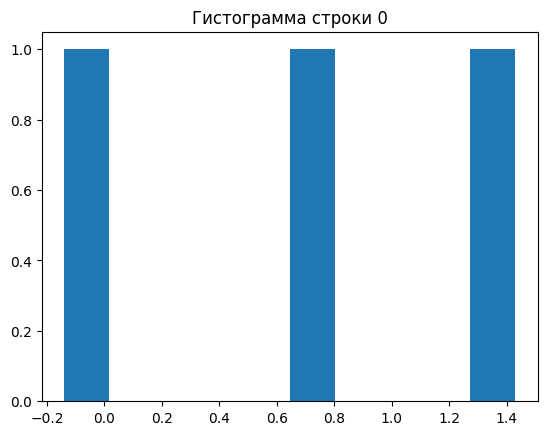

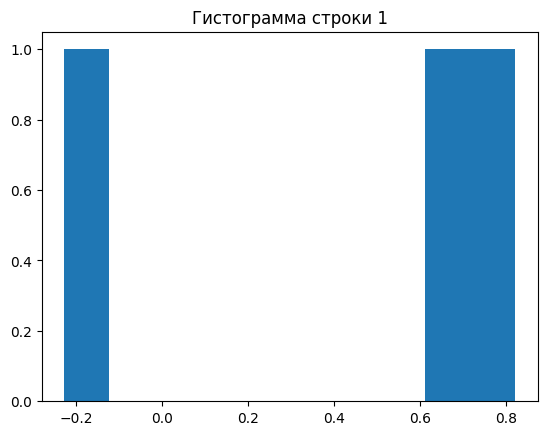

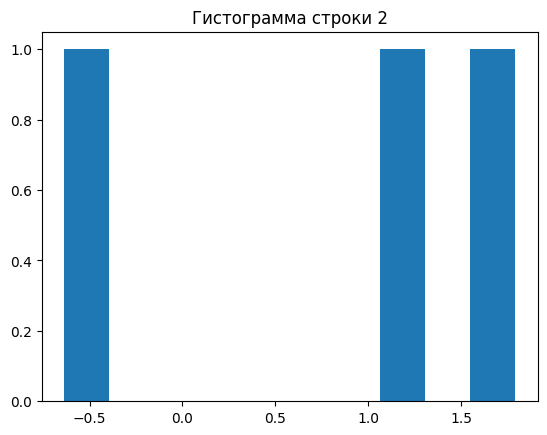

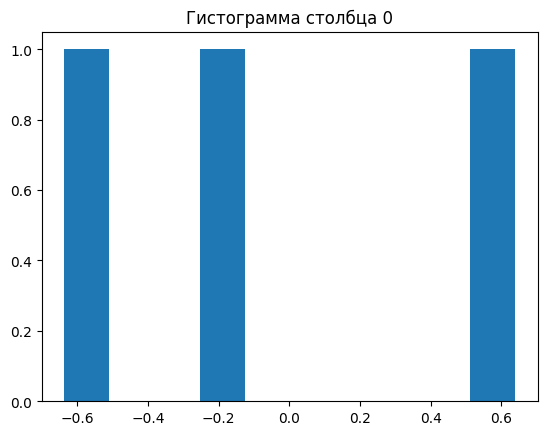

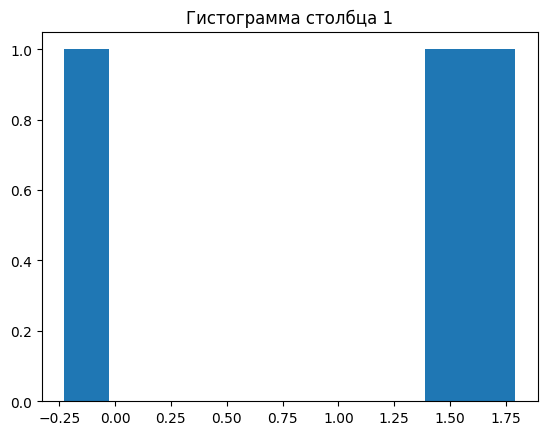

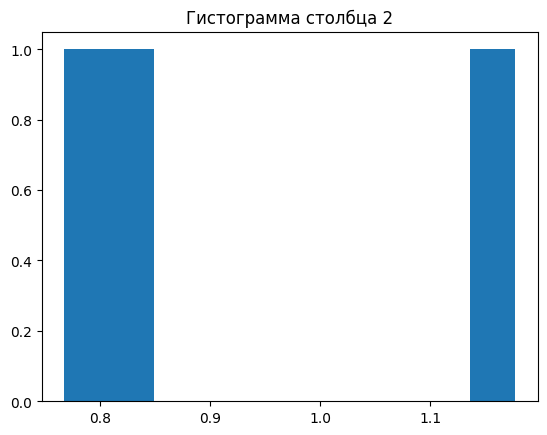


Сгенерированная матрица:
[[ 0.388 -1.594]
 [-1.351  0.635]]
Мат. ожидание по строкам: [-0.60275365 -0.35798126]
Дисперсия по строкам: [0.98243712 0.98588797]
Мат. ожидание по столбцам: [-0.48123708 -0.47949783]
Дисперсия по столбцам: [0.7563139  1.24196645]


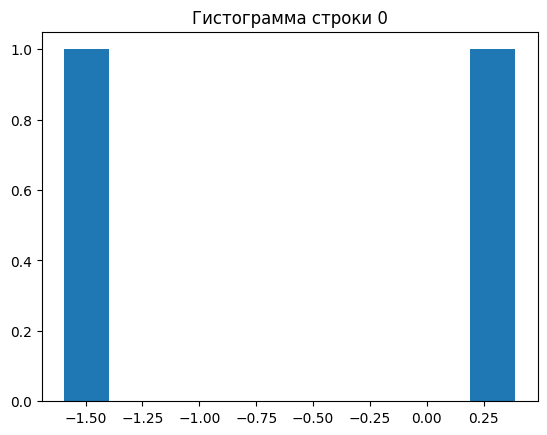

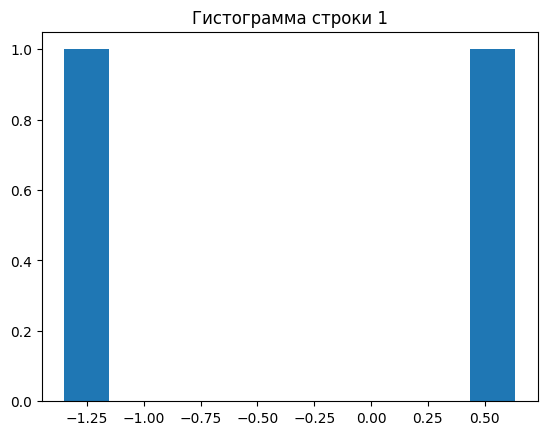

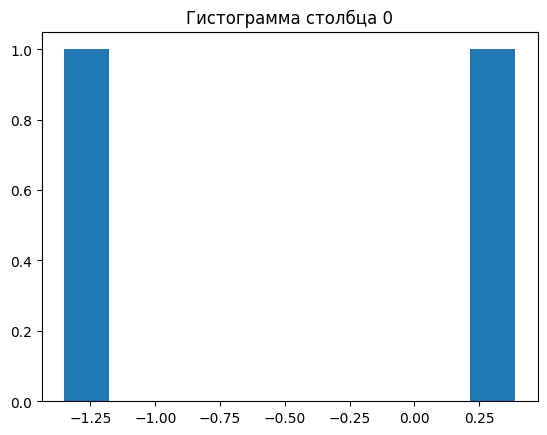

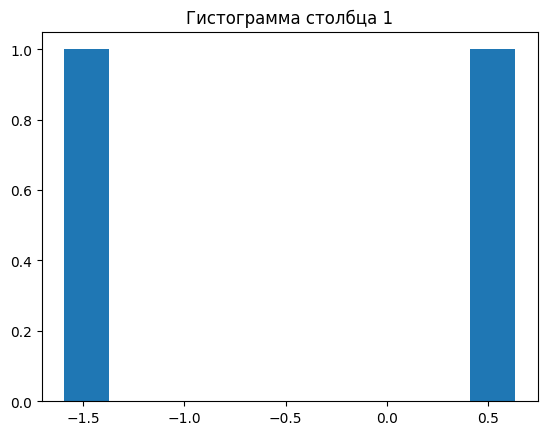

array([[ 0.38842602, -1.59393331],
       [-1.35090017,  0.63493766]])

In [43]:
def analyze_matrix(m, n):
    M = np.random.randn(m, n)

    print("\nСгенерированная матрица:")
    print(np.round(M, 3))

    row_means = M.mean(axis=1)
    row_vars = M.var(axis=1)

    col_means = M.mean(axis=0)
    col_vars = M.var(axis=0)

    print("Мат. ожидание по строкам:", row_means)
    print("Дисперсия по строкам:", row_vars)
    print("Мат. ожидание по столбцам:", col_means)
    print("Дисперсия по столбцам:", col_vars)

    # Гистограммы по строкам
    for i in range(m):
        plt.hist(M[i], bins=10)
        plt.title(f"Гистограмма строки {i}")
        plt.show()

    # Гистограммы по столбцам
    for j in range(n):
        plt.hist(M[:, j], bins=10)
        plt.title(f"Гистограмма столбца {j}")
        plt.show()

    return M


analyze_matrix(3, 3)
analyze_matrix(2, 2)

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [42]:
def chess(m, n, a, b):
    M = np.empty((m, n), dtype=type(a))
    for i in range(m):
        for j in range(n):
            M[i, j] = a if (i + j) % 2 == 0 else b
    return M


assert np.array_equal(
    chess(2, 2, 1, 0),
    np.array([[1, 0],
              [0, 1]])
)

assert np.array_equal(
    chess(3, 3, 3, 2),
    np.array([[3, 2, 3],
              [2, 3, 2],
              [3, 2, 3]])
)


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

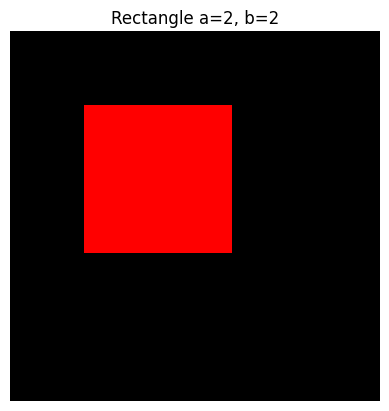

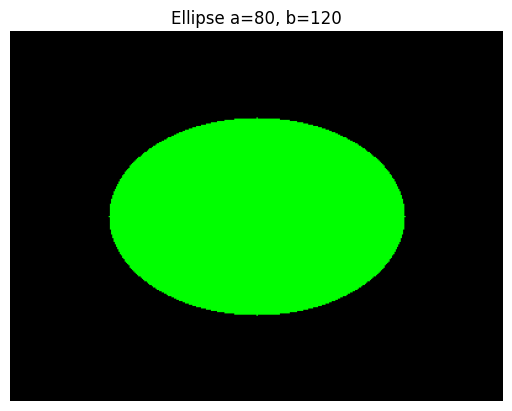

In [41]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color, show=True):
    img = np.full((m, n, 3), background_color, dtype=int)

    start_row = (m - a) // 2
    start_col = (n - b) // 2

    img[start_row:start_row + a, start_col:start_col + b] = rectangle_color

    if show:
        plt.imshow(img)
        plt.title(f"Rectangle a={a}, b={b}")
        plt.axis('off')
        plt.show()
    return img


def draw_ellipse(a, b, m, n, ellipse_color, background_color, show=True):
    img = np.full((m, n, 3), background_color, dtype=int)

    center_x, center_y = m // 2, n // 2

    for x in range(m):
        for y in range(n):
            if ((x - center_x)**2) / a**2 + ((y - center_y)**2) / b**2 <= 1:
                img[x, y] = ellipse_color

    if show:
        plt.imshow(img)
        plt.title(f"Ellipse a={a}, b={b}")
        plt.axis('off')
        plt.show()

    return img


rect = draw_rectangle(2, 2, 5, 5, (255, 0, 0), (0, 0, 0))
assert np.all(rect[2, 2] == (255, 0, 0))

ell = draw_ellipse(80, 120, 300, 400, (0, 255, 0), (0, 0, 0))
assert np.all(ell[300 // 2, 400 // 2] == (0, 255, 0))

center_x, center_y = 300 // 2, 400 // 2
assert np.all(ell[center_x, center_y + 120] == (0, 255, 0))
assert np.all(ell[center_x, center_y + 121] == (0, 0, 0))



<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [39]:
def analyze_series(series, p):
    series = np.array(series)

    mean = series.mean()
    var = series.var()
    std = series.std()

    maxima = []
    minima = []

    for i in range(1, len(series) - 1):
        if series[i] > series[i - 1] and series[i] > series[i + 1]:
            maxima.append(i)
        if series[i] < series[i - 1] and series[i] < series[i + 1]:
            minima.append(i)

    moving_avg = [series[i:i + p].mean() for i in range(len(series) - p + 1)]

    return mean, var, std, maxima, minima, moving_avg


mean, var, std, maxs, mins, mov = analyze_series([1,3,2,4,3], 2)

assert mean == 2.6
assert var == np.var([1,3,2,4,3])
assert maxs == [1, 3]
assert mins == [2]
assert np.allclose(mov, [2, 2.5, 3, 3.5])

mean, var, std, maxs, mins, mov = analyze_series([1,2,3,4,5], 2)
assert maxs == []
assert mins == []

mean, var, std, maxs, mins, mov = analyze_series([1,3,1,3,1], 2)
assert maxs == [1, 3]
assert mins == [2]

mean, var, std, maxs, mins, mov = analyze_series([-1, 0, -2, 0, -1], 2)
assert maxs == [1, 3]
assert mins == [2]

_, _, _, _, _, mov = analyze_series([1,2,3], 5)
assert mov == []

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [38]:
def one_hot_encode(labels):
    labels = np.array(labels)
    classes = labels.max() + 1
    result = np.zeros((len(labels), classes), dtype=int)

    for i, label in enumerate(labels):
        result[i, label] = 1

    return result


assert np.array_equal(
    one_hot_encode([0, 2, 3, 0]),
    np.array([[1,0,0,0],
              [0,0,1,0],
              [0,0,0,1],
              [1,0,0,0]])
)

assert np.array_equal(one_hot_encode([1,1,1]), np.array([[0,1],[0,1],[0,1]]))

assert np.array_equal(
    one_hot_encode([2,0,1]),
    np.array([
        [0,0,1],
        [1,0,0],
        [0,1,0],
    ])
)